In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import statistics

In [5]:
from sklearn import preprocessing 
# preprocessing -> provides tools to transform raw data into a clean, scaled, and model-ready format.

In [6]:
df = pd.read_csv("churn_modeling.csv")

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,1,1.00,1,101348.88,1,NaN,NaN
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0.00,1,112542.58,0.0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1.00,0,113931.57,1.0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0.00,0,93826.63,0.0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1.00,1,79084.10,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  float64
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  9999 non-null   float64
 13  Exited           9999 non-null   float64
dtypes: float64(4), int64(7), object(3)
memory usage: 1.1+ MB


In [ ]:
df.drop(columns=['CustomerId','RowNumber','Surname'], axis=1, inplace=True) #inplace=True makes permanent changes to the original DataFrame.

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,1,1.00,1,101348.88,1,NaN,NaN
1,608,Spain,Female,41,1,83807.86,1,0.00,1,112542.58,0.0
2,502,France,Female,42,8,159660.80,3,1.00,0,113931.57,1.0
3,699,France,Female,39,1,0.00,2,0.00,0,93826.63,0.0
4,850,Spain,Female,43,2,125510.82,1,1.00,1,79084.10,0.0


In [14]:
print(df.Age.min())
print(df.Age.max())

18
92


In [17]:
labels = ['0-20', '21-40', '41-60', 'Above 60']
bins = [0, 20, 40, 60, 100]
# pd.cut() -> divides numeric data into ranges (bins).
# include_lowest=True -> This means the lowest value of the first bin is included.
df['Age_bins'] = pd.cut(df.Age, bins, labels=labels, include_lowest=True)

In [19]:
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_bins
9995,771,France,Male,39,5,0.00,2,1.0,0,96270.64,0.0,21-40
9996,516,France,Male,35,10,57369.61,1,1.0,1,101699.77,0.0,21-40
9997,709,France,Female,36,7,0.00,1,0.0,1,42085.58,1.0,21-40
9998,772,Germany,Male,42,3,75075.31,2,1.0,0,92888.52,1.0,41-60
9999,792,France,Female,28,4,130142.79,1,1.0,0,38190.78,0.0,21-40


In [ ]:
df[['Age','Age_bins']].to_csv('test.csv') # ek new csv file me age & age_bins ko compare kara hai!, here test.csv has been created.

In [ ]:
# lets check counts of age jo bin ki range me fall hoti hain.
df.Age_bins.value_counts()
# here we got an insight-> majority of the customers 21-40 age ke hain.

Age_bins
21-40       6330
41-60       3117
Above 60     464
0-20          89
Name: count, dtype: int64

Text(0, 0.5, 'Age count')

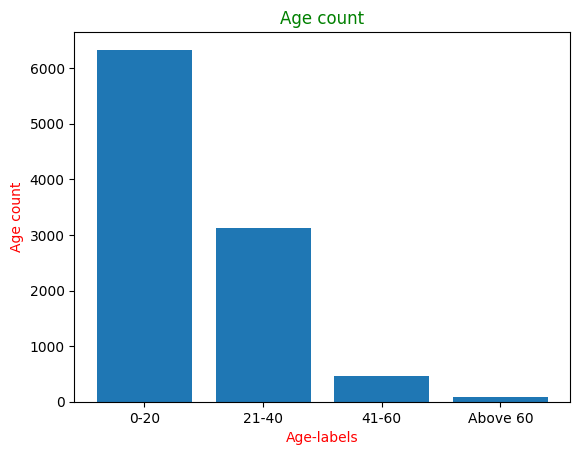

In [31]:
plt.Figure(figsize=(10,7))
plt.bar(labels, df.Age_bins.value_counts())
plt.title("Age count",color="Green")
plt.xlabel("Age-labels", color ="red")
plt.ylabel("Age count", color = "red")
